In [19]:
import json
import numpy as np
import pandas as pd
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sn

from pathlib import Path

plt.rcParams['figure.figsize'] = [12.5, 5]
# sn.set_theme(style="darkgrid", font_scale=2)
sn.set_theme(style="ticks", font_scale=1.3)

In [20]:
# directory of the experiment
# DATASET = "fashionmnist"
# DATASET = "cifar10"
DATASET = "cifar100"

TEST = "denser_with_power_measure"

TEST_DIR = f"../experiments/{DATASET}/{TEST}"

runs_dirs = tuple(i for i in Path(TEST_DIR).iterdir() if i.is_dir())
# runs_dirs = tuple(i for i in Path(TEST_DIR).iterdir() if i.is_dir() and str(i).endswith('run_0'))
n = len(runs_dirs)

layer_types = ('conv', 'batch_norm', 'pool_avg', 'pool_max', 'dropout', 'fc')
layer_types = tuple(f"layer:{i}" for i in layer_types)
# data = [None] * n_runs
simple_fields = ('id', 'phenotype', 'num_epochs', 'is_valid_solution',
                 'fitness', 'n_trainable_parameters', 'n_layers',
                 'total_epochs_trained')
data = pd.DataFrame(columns=['run', 'gen', *simple_fields, 'accuracy',
                             'power_train',
                             'power_test_mean', 'power_test_std',
                             'energy_train',
                             'energy_test_mean', 'energy_test_std', 'batch_size'])
data.head()

,run,gen,id,phenotype,num_epochs,is_valid_solution,fitness,n_trainable_parameters,n_layers,total_epochs_trained,accuracy,power_train,power_test_mean,power_test_std,energy_train,energy_test_mean,energy_test_std,batch_size


In [21]:
# adds all data into a pd.DataFrame
for run in runs_dirs:
    gens_dir = tuple(i for i in Path(run).glob('statistics/*.json'))
    run = int(run.name[run.name.find('_')+1:])
    for gen in gens_dir:
        if str(gen).split('/')[-1] == "test_accuracies.json":
            continue
        with open(gen) as file:
            gen_data = json.load(file)
        gen = int(gen.name[gen.name.find('_')+1:gen.name.find('.')])
        ###############
        if gen > 149:
            continue
        ###############
        for ind in gen_data:
            pairs = ind['phenotype'].split()
            phenotype_dict = dict(pair.split(':') for pair in pairs)
            batch_size = int(phenotype_dict.get('batch_size'))
            if ind['is_valid_solution']:
                power = [ind['power']['train']['power'],
                        ind['power']['test']['power']['mean'], ind['power']['test']['power']['std'],
                        ind['power']['train']['energy'],
                        ind['power']['test']['energy']['mean'], ind['power']['test']['energy']['std']]
                other_info = [ind['accuracy']]
            else:
                power = [np.nan] * 6
                other_info = [np.nan] * 1
            data.loc[len(data)] = [run, gen, *(ind[field] for field in simple_fields),
                                   *other_info,
                                   *power,
                                   batch_size]
data = data[data['is_valid_solution']]
for layer_type in layer_types:
    count = data['phenotype'].str.count(layer_type)
    n_layers = data['n_layers']
    if layer_type == 'fc':
        count -= 1
        n_layers -= 1
    data[layer_type] = count / n_layers

In [22]:
data.groupby('run')['gen'].max()

run
0    149
1    149
2    149
3    149
4    149
Name: gen, dtype: int64

In [23]:
best_indices = data.groupby(['run', 'gen'])['fitness'].idxmax()
best_rows_df = data.loc[best_indices]
data = best_rows_df.reset_index(drop=True)
data.head()

,run,gen,id,phenotype,num_epochs,is_valid_solution,fitness,n_trainable_parameters,n_layers,total_epochs_trained,...,energy_train,energy_test_mean,energy_test_std,batch_size,layer:conv,layer:batch_norm,layer:pool_avg,layer:pool_max,layer:dropout,layer:fc
0,0,0,2,layer:pool_avg kernel_size:3 stride:1 padding:...,154,True,0.0570,2265300,3,154,...,26340.839,31.419133,4.678477,159,0.0,0.00,0.333333,0.0,0.0,0.666667
1,0,1,1,layer:pool_avg kernel_size:3 stride:1 padding:...,165,True,0.0594,2265300,3,165,...,27430.822,31.643767,4.932932,159,0.0,0.00,0.333333,0.0,0.0,0.666667
2,0,2,4,layer:pool_avg kernel_size:3 stride:1 padding:...,166,True,0.1052,2265306,5,166,...,28259.546,34.683267,5.686267,159,0.0,0.20,0.200000,0.0,0.2,0.400000
3,0,3,2,layer:pool_avg kernel_size:3 stride:1 padding:...,332,True,0.1108,2265306,5,332,...,29412.254,33.910667,4.975832,159,0.0,0.20,0.200000,0.0,0.2,0.400000
4,0,4,2,layer:pool_avg kernel_size:3 stride:1 padding:...,490,True,0.1262,4849706,4,490,...,63145.751,35.174333,3.601552,159,0.0,0.25,0.250000,0.0,0.0,0.500000


In [24]:
best = data.iloc[data['fitness'].idxmax()]

print(f"Run {best['run']} Gen {best['gen']} Fitness {best['fitness']}")
print(best['phenotype'])
print(best)

Run 2 Gen 148 Fitness 0.5044
layer:conv out_channels:138 kernel_size:3 stride:1 padding:valid act:relu bias:False input:-1 layer:batch_norm input:0 layer:conv out_channels:138 kernel_size:3 stride:1 padding:valid act:relu bias:False input:1 layer:pool_avg kernel_size:2 stride:2 padding:valid input:2 layer:conv out_channels:223 kernel_size:4 stride:1 padding:same act:relu bias:True input:3 layer:batch_norm input:4 layer:dropout rate:0.6035389276370904 input:5 layer:fc act:softmax out_features:100 bias:True input:6 learning:gradient_descent lr:0.038618031547120804 momentum:0.6933799086972249 weight_decay:0.0008571130679666025 nesterov:False early_stop:20 batch_size:235 epochs:10000
run                                                                       2
gen                                                                     148
id                                                                        1
phenotype                 layer:conv out_channels:138 kernel_size:3 stri...
num_epo

In [7]:
data.to_csv(f"{TEST_DIR}/data.csv", index=False)

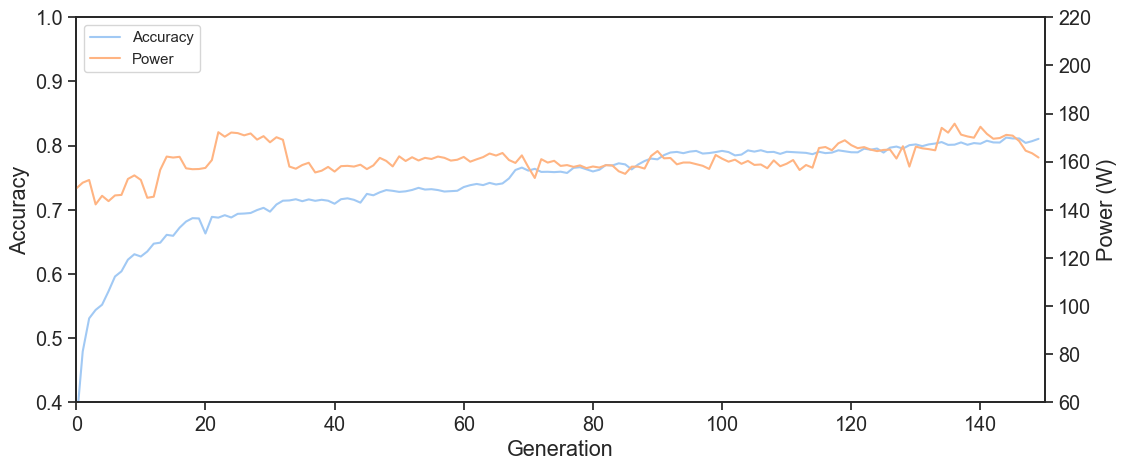

In [9]:
fig, ax1 = plt.subplots()

palette = sn.color_palette("pastel", 2) * 2
palette.sort()

sn.lineplot(data, x='gen', y='accuracy', label='Accuracy', ax=ax1, color=palette[0], linestyle='-', errorbar=None)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.4, 1)

ax2 = ax1.twinx()
sn.lineplot(data=data, x='gen', y='power_test_mean', label='Power', ax=ax2, color=palette[2], linestyle='-', errorbar=None)
ax2.set_ylabel("Power (W)")
ax2.set_ylim(60, 220)


ax1.set_xlim(0, 150)
ax2.set_xlim(0, 150)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize='x-small')
ax2.get_legend().remove()

plt.savefig(f"figures/{TEST}_accuracypower.pdf", bbox_inches='tight')
plt.show()

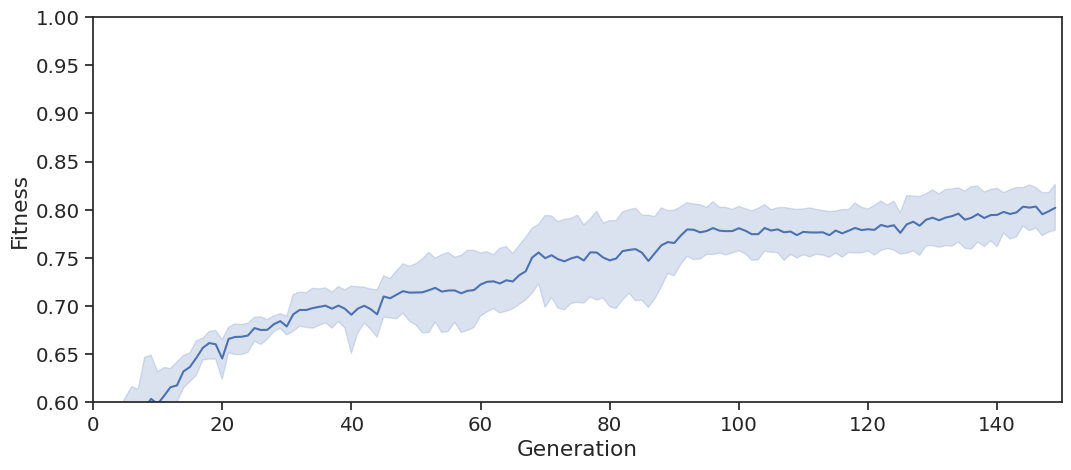

In [8]:
sn.lineplot(data, x='gen', y='fitness')
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.xlim(0, 150)
plt.ylim(0.6, 1)
# plt.savefig(f"figures/{TEST}_fitness.pdf", bbox_inches='tight')
plt.show()

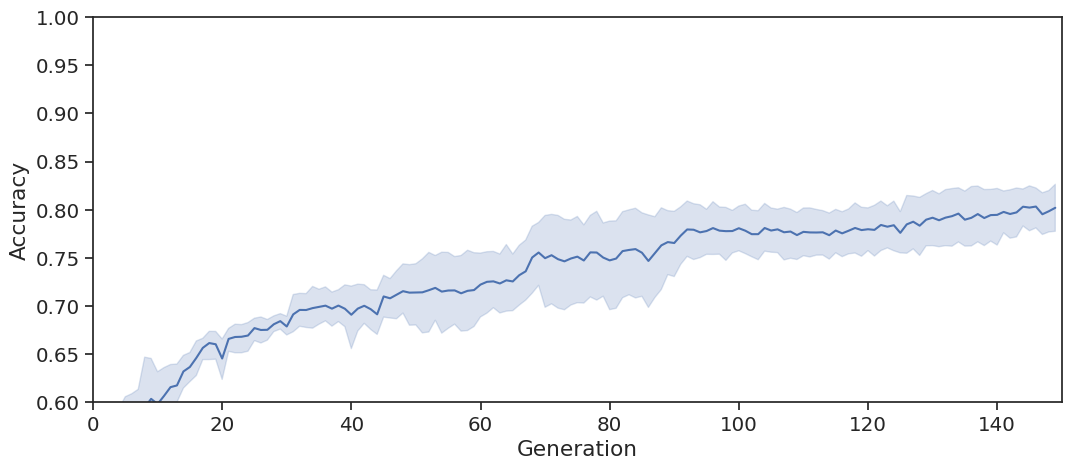

In [9]:
sn.lineplot(data, x='gen', y='accuracy', label='Accuracy')
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.xlim(0, 150)
plt.ylim(0.6, 1)
plt.legend().remove()
plt.savefig(f"figures/{TEST}_accuracy.pdf", bbox_inches='tight')
plt.show()

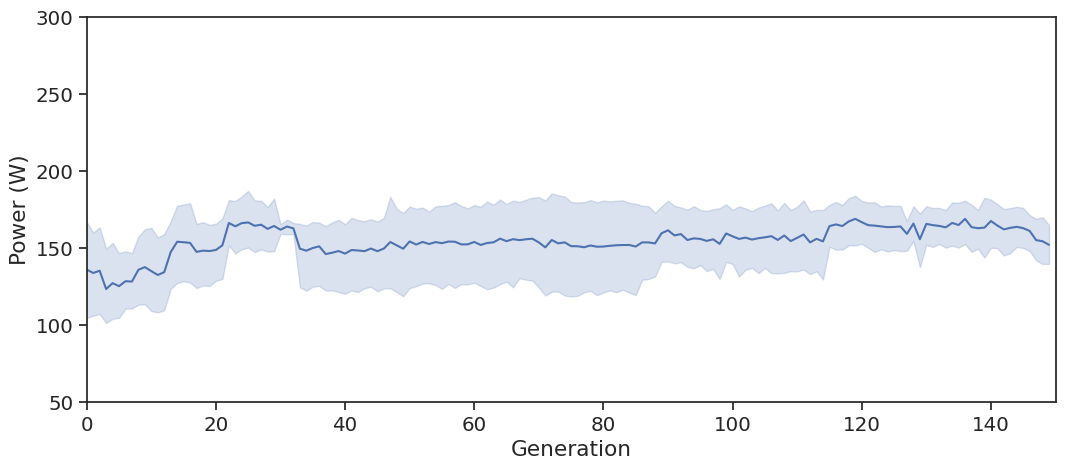

In [10]:
sn.lineplot(data, x='gen', y='power_test_mean', label='Power')
plt.xlabel("Generation")
plt.ylabel("Power (W)")
plt.xlim(0, 150)
plt.ylim(50, 300)
plt.legend().remove()
plt.savefig(f"figures/{TEST}_power.pdf", bbox_inches='tight')
plt.show()

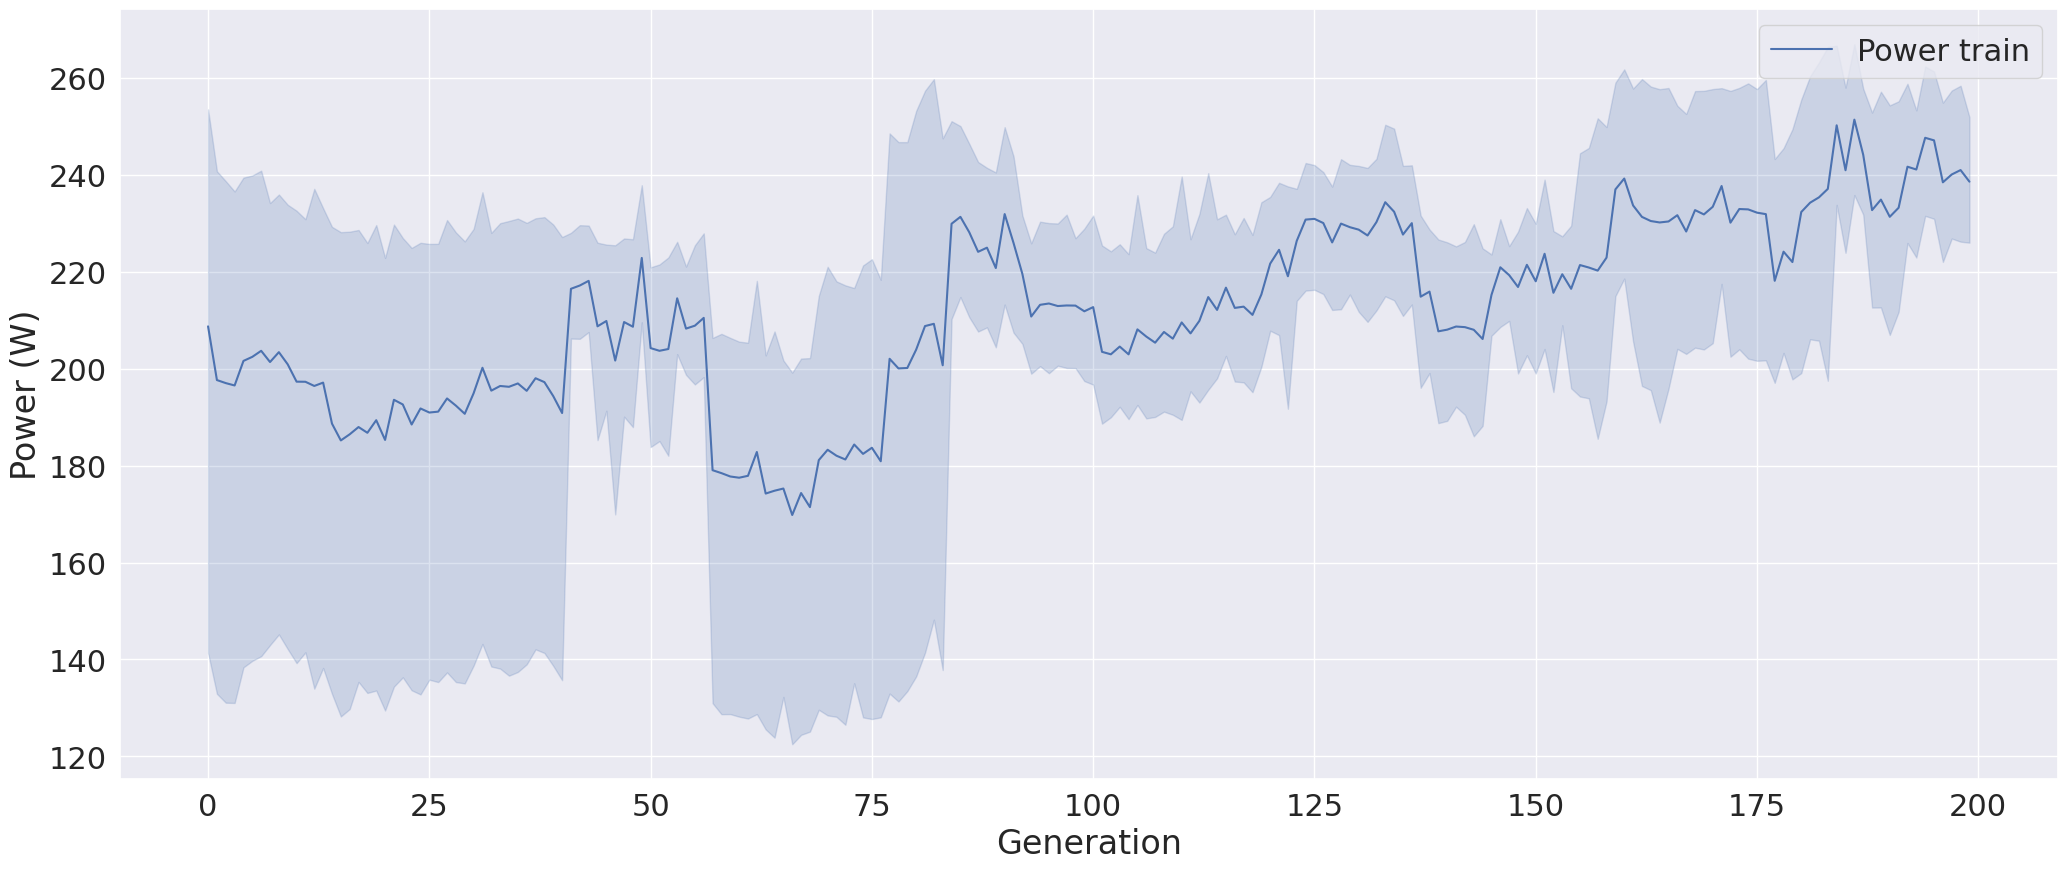

In [12]:
sn.lineplot(data, x='gen', y='power_train', label='Power train')
plt.xlabel("Generation")
plt.ylabel("Power (W)")
plt.show()

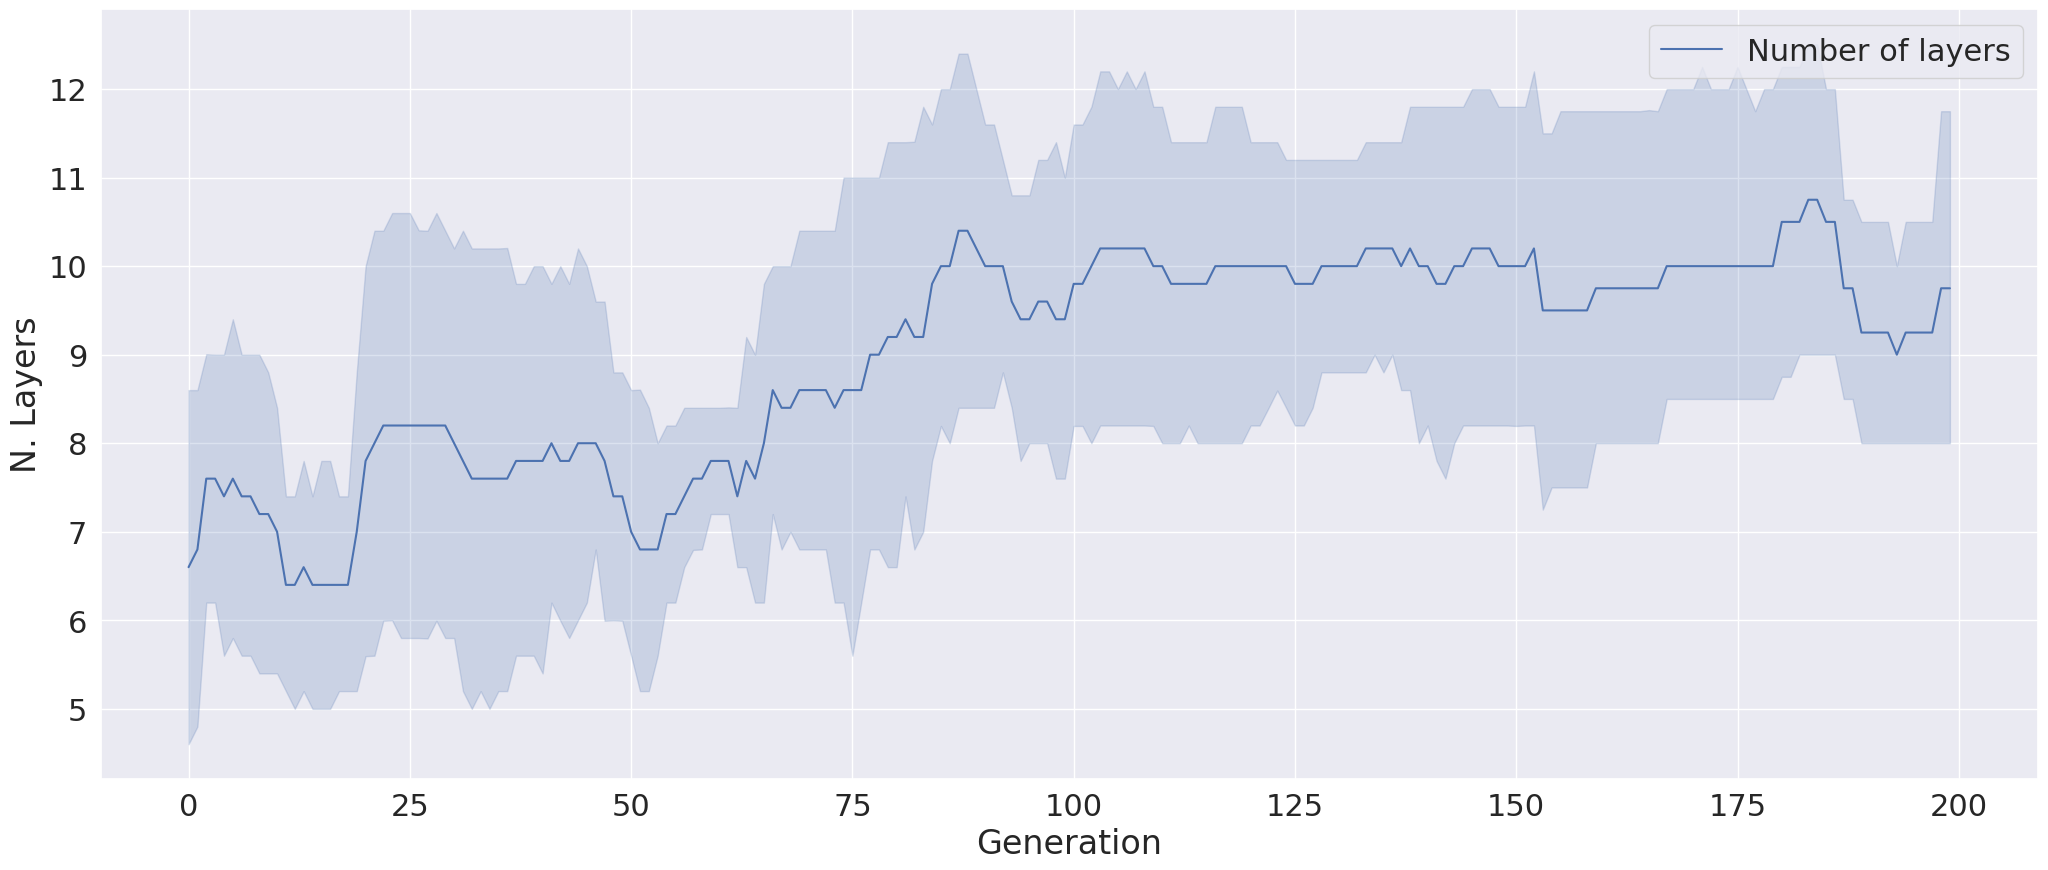

In [13]:
sn.lineplot(data, x='gen', y='n_layers', label='Number of layers')
plt.xlabel("Generation")
plt.ylabel("N. Layers")
plt.show()

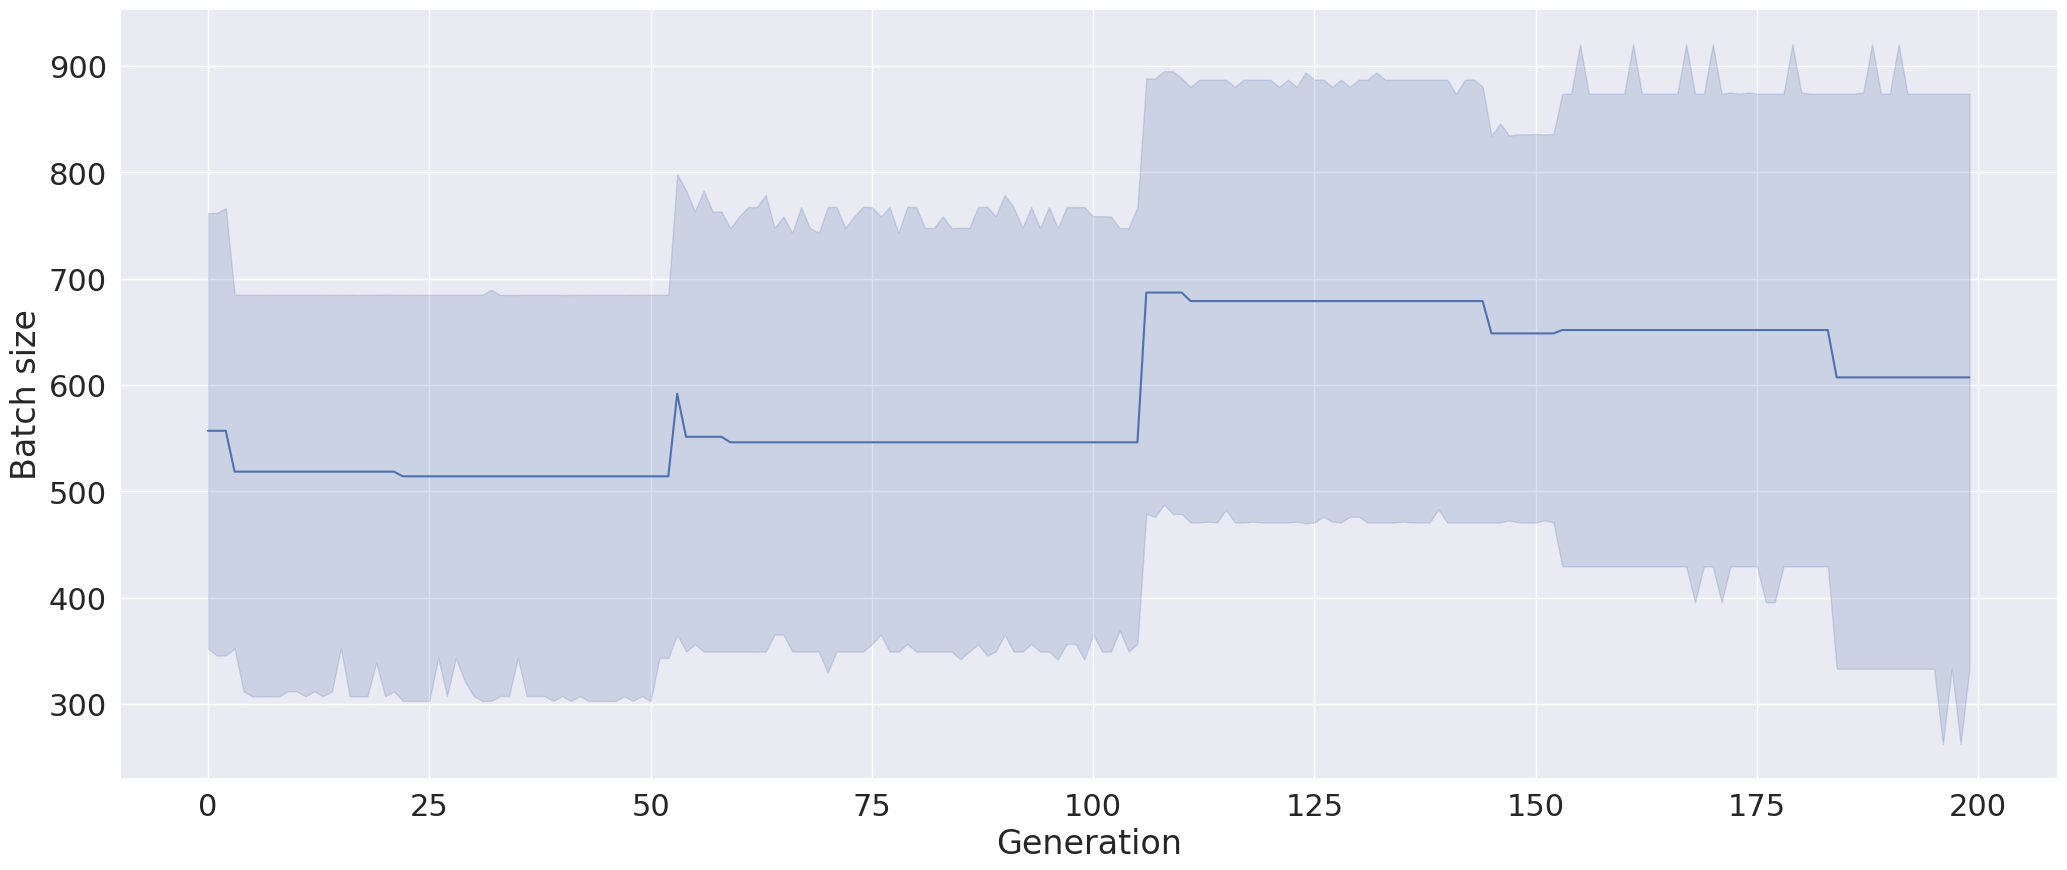

In [14]:
sn.lineplot(data, x='gen', y='batch_size')
plt.xlabel("Generation")
plt.ylabel("Batch size")
plt.show()

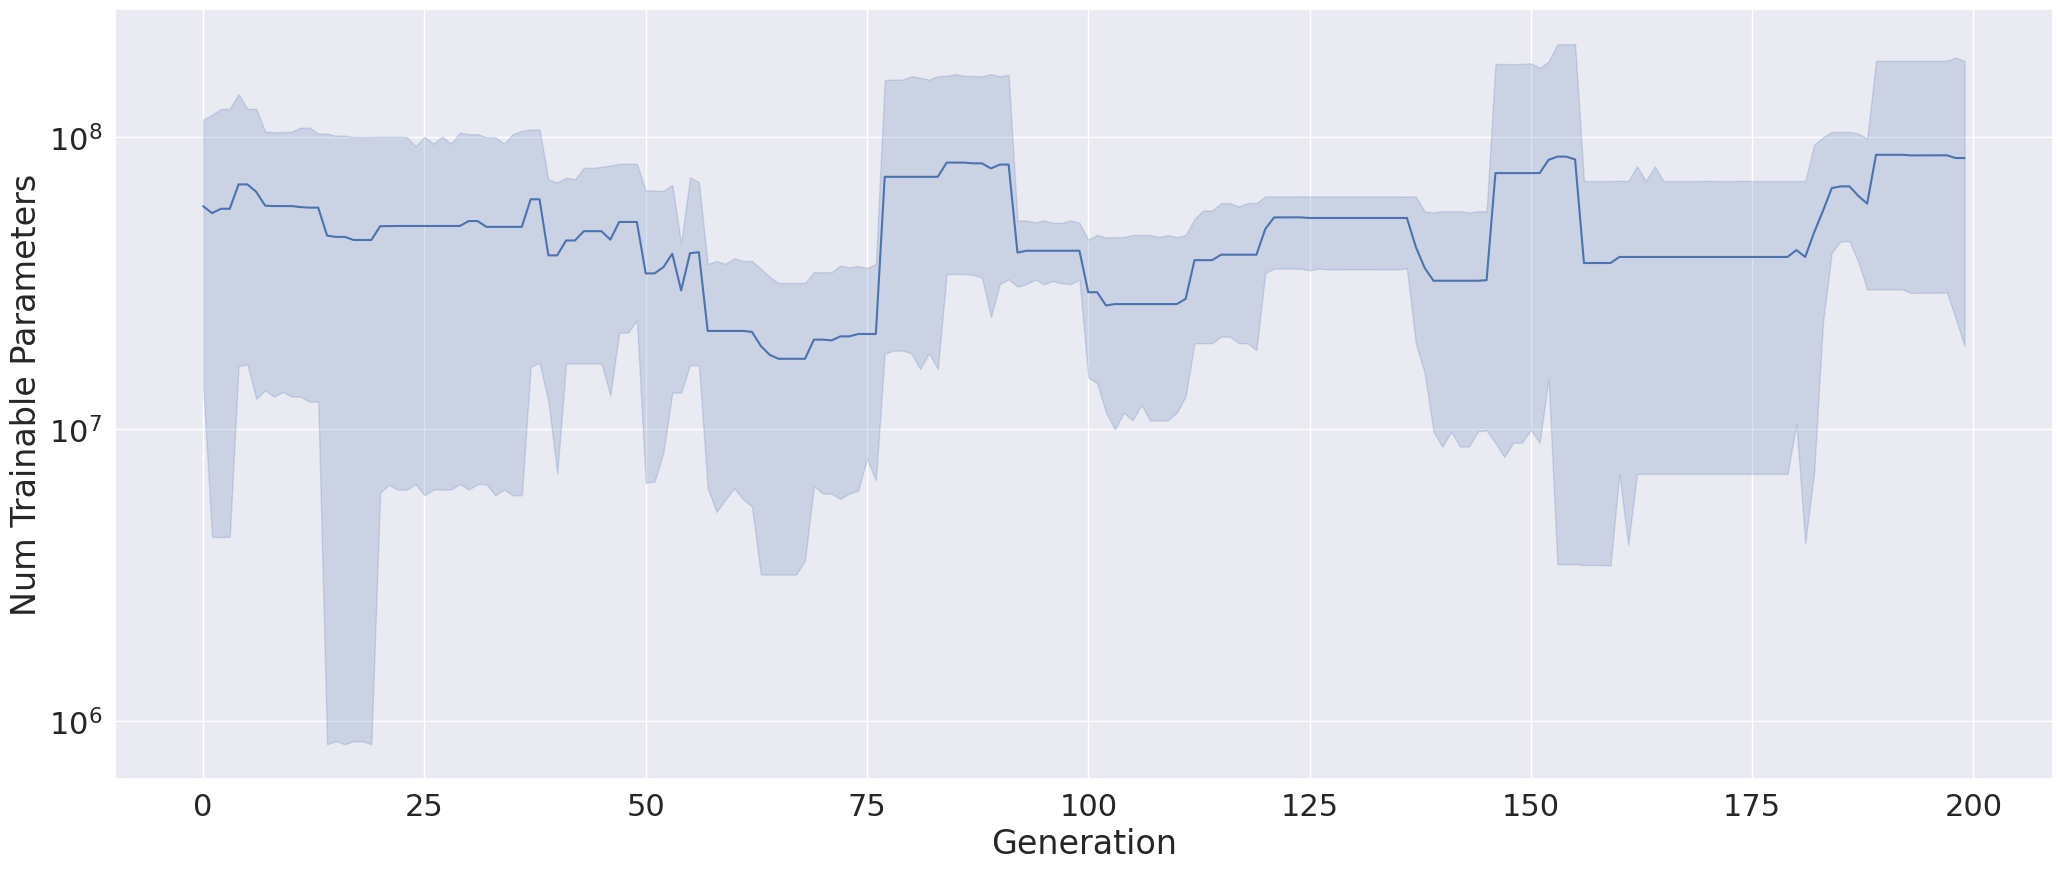

In [15]:
sn.lineplot(data, x='gen', y='n_trainable_parameters')
plt.xlabel("Generation")
plt.ylabel("Num Trainable Parameters")
plt.yscale('log')
plt.show()

<Figure size 1600x800 with 0 Axes>

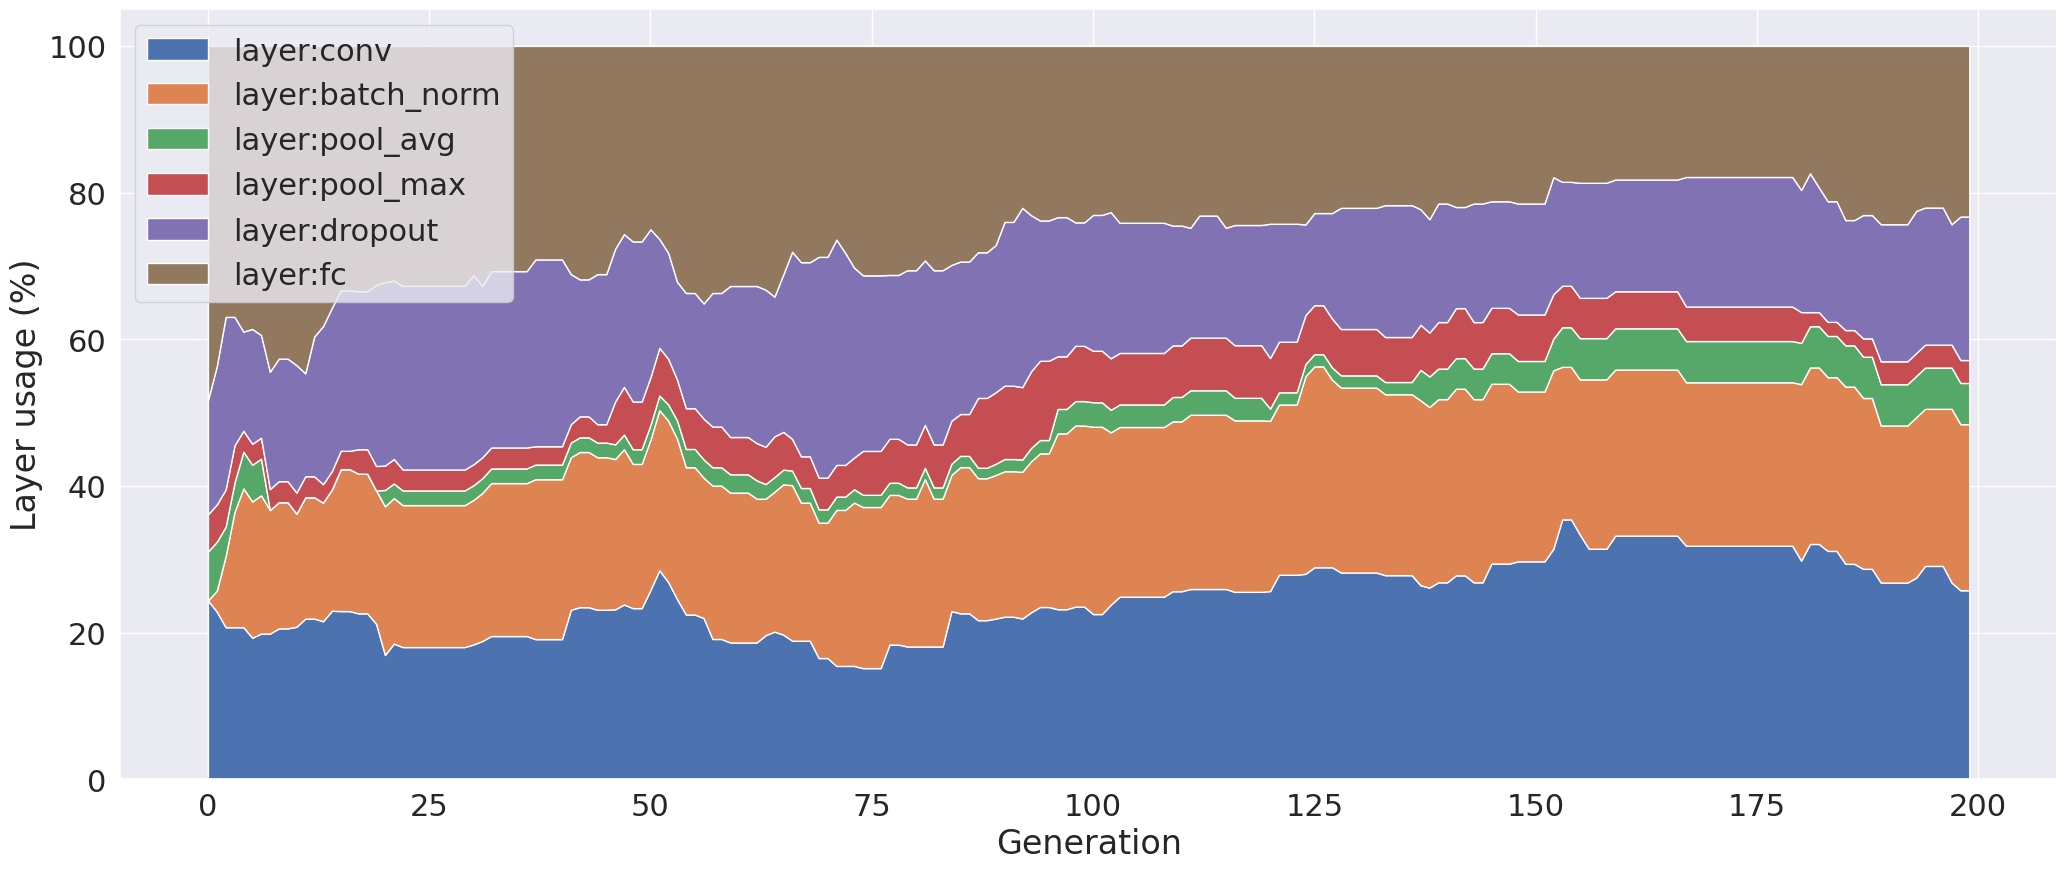

In [16]:
plt.figure(figsize=[16,8])
plt.figure()
y = data.groupby('gen')[list(layer_types)].mean() * 100
plt.stackplot(range(len(y)), y.transpose().values.tolist(), labels=layer_types)
plt.legend(loc='upper left')
plt.xlabel("Generation")
plt.ylabel("Layer usage (%)")
plt.show()